# Hands-On Demo: LLM-Powered Database Agent
## Overview
This notebook showcases a  LLM-powered database agent using **LangChain** and **GPT-4o**, designed to show how businesses interact with data. By enabling natural language queries, context retention, and robust security measures, we empower non-technical users (e.g., marketing managers, executives) to extract insights without SQL expertise

## Objectives
- **Package Installation**:  Overview of Python libraries used for building the agent
- **Set up database**: Create a database with `customers`,`cards`,`marchant_category` and `transactions` tables.
- **Query with natural language**: Convert a business question into SQL using LangChain and GPT-4o.
- **Writing Customer Prompts**: Understand how to write custom prompts to generate accurate results.
- **Demonstrate context retention**: Handle follow-up queries using conversational memory to maintain query context, showcasing advanced LLM capabilities.
- **Visualize results**: Uderstand how to enerate multiple visualizations (bar and line charts) for actionable insights
- **Secure against SQL injection**: Understand SQL injection, how to prevent such attacks, with an example of handling a malicious query.
- **Advanced debugging and monitoring**: Understand how  LangChain’s `AgentExecutor` helps in structured logging for  error handling and performance tracking



## **Step1:** Tech Stack Overview and Install Dependencies

### Purpose
To enable our advanced database agent, we will be using following:

**Environment:** Google Colab with Python 3.11+.

**LLM:** GPT-4o from OpenAI (API Key: Obtain open ai key and store securely in Colab’s secret storage)

<br>

### We will also need a robust set of Python libraries. These include:

**langchain**: Orchestrates LLM interactions and database connections.

**langchain-openai**: Integrates GPT-4o for natural language processing and SQL generation

**langchain-experimental**: Provides `AgentExecutor` for advanced query execution and monitoring

**sqlite3**: Built-in Python library for managing our in-memory database

**pandas**: For displaying and manipulating query results in a user-friendly format

**matplotlib**: For creating professional visualizations (bar and line charts).
### Why It Matters
These tools form the backbone of our agent, enabling seamless integration of LLMs with databases and delivering visual outputs for business stakeholders.  By installing all dependencies upfront, we ensure a smooth demo experience in Colab.

### Implementation
Run the cell below to install the required libraries. This step is critical to prepare the environment for database setup, querying, and visualization.

In [ ]:
!python --version

Python 3.11.13


In [ ]:
!pip install langchain==0.3.27  langchain-openai==0.3.28 openai==1.97.1 langchain-experimental==0.3.4  pandas==2.2.2 matplotlib==3.10.0
#sqlite3 is already part of python and hence does not need separate installation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 764.4/764.4 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.99.1
    Uninstalling openai-1.99.1:
      Successfully uninstalled openai-1.99.1


 ## Objective:
 We will cover following topics in this session



*   Setup a database
*   Build and execute a basic database agent
  *   How to use LangChain’s SQL toolkit
  *   How to write custom prompts
  *   Add memory retain context



 ## Step 2: Set Up the Database

We’ll create a financial services database. I will be using financial transactions dataset
https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets?resource=download

####We will create total 4 tables:

**Table1: customers**

It will use users_data.csv

It contains demographic information and account-related details about customers

 **Table2: transactions**

 It will use transactions_data.csv

 It contains detailed transaction records including amounts, timestamps, and merchant details

 **Table3: cards**:

 It will use cards_data.csv

 It links to customer accounts via card_id and is essential for understanding customer financial profiles

 **Table4: merchant_category**:

 It will use mcc_codes.json

 It contains Industry-standard MCC codes with description and will enables transaction categorization and spending analysis


### Implementation
Let's create these four tables by inserting data from csv and json files.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Read the dataset
import pandas as pd

customers_df = pd.read_csv('/content/drive/MyDrive/database/users_data.csv')
cards_df = pd.read_csv('/content/drive/MyDrive/database/cards_data.csv')
transactions_df_sample = pd.read_csv('/content/drive/MyDrive/database/transactions_data.csv',nrows=5)

In [ ]:
from IPython.display import display

print("Customers:")
display(customers_df.head())

print("Transactions:")
display(transactions_df_sample.head())

print("Cards:")
display(cards_df.head())

Customers:


,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


Transactions:


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


Cards:


,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


## Data Preprocessing
1. Convert amount type fields to float
2. Rename confusing columns
3. Normalize date

In [ ]:
import pandas as pd

def clean_currency_columns(df: pd.DataFrame, currency_cols):
    """
    Remove $ and commas from given currency columns and convert to float.
    Also rename columns to add '_usd' suffix.
    """
    df = df.copy()
    for col in currency_cols:
        # Remove $ and commas, convert to float
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(r"[\$,]", "", regex=True)
            .astype(float)
        )
        # Rename column with _usd suffix
        df.rename(columns={col: f"{col}_usd"}, inplace=True)
    return df


In [ ]:
currency_columns = ["per_capita_income", "yearly_income", "total_debt"]
customers_df_clean = clean_currency_columns(customers_df, currency_columns)

currency_columns = ["credit_limit"]
cards_df_clean = clean_currency_columns(cards_df, currency_columns)

In [ ]:
# Let's rename the confusing columns
customers_df_clean.rename(columns={"id": "customer_id"}, inplace=True)
cards_df_clean.rename(columns={"id": "account_id","client_id":"customer_id"}, inplace=True)

In [ ]:
from IPython.display import display

print("Customers:")
display(customers_df_clean.head())

print("Cards:")
display(cards_df_clean.head())

Customers:


,customer_id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,37891.0,77254.0,191349.0,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,22681.0,33483.0,196.0,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,163145.0,249925.0,202328.0,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,53797.0,109687.0,183855.0,675,1


Cards:


,account_id,customer_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit_usd,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,24295.0,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,21968.0,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,46414.0,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,12400.0,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,28.0,09/2008,2009,No


In [ ]:
# Load your DataFrames into your SQLite database using SQLAlchemy

import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('sqlite:///drive/MyDrive/database/mydb.db') # creating a connection object to a SQLite database file using SQLAlchemy.


In [ ]:
# Load customer as a SQL table
customers_df_clean.to_sql('customers', engine, if_exists='replace', index=False)
del customers_df_clean

In [ ]:
cards_df_clean.head()

,account_id,customer_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit_usd,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,24295.0,2002-09-01,2008,No
1,2731,825,Visa,Debit,4956965974959986,2020-12-01,393,YES,2,21968.0,2014-04-01,2014,No
2,3701,825,Visa,Debit,4582313478255491,2024-02-01,719,YES,2,46414.0,2003-07-01,2004,No
3,42,825,Visa,Credit,4879494103069057,2024-08-01,693,NO,1,12400.0,2003-01-01,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,2009-03-01,75,YES,1,28.0,2008-09-01,2009,No


In [ ]:

# Date normalization: Convert MM/YYYY -> YYYY-MM-01
for col in ["expires", "acct_open_date"]:
    cards_df_clean[col] = pd.to_datetime(cards_df_clean[col], format="%m/%Y").dt.strftime("%Y-%m-%d")



In [ ]:

# Load cards as a SQL table
cards_df_clean.to_sql('cards', engine, if_exists='replace', index=False)
del cards_df_clean

In [ ]:
# Read transaction data into chunks of 50000 and perform prepocessing. Total records in this dataset is 13,305,915
currency_columns = ["amount"]
chunksize = 50000

csv_path = '/content/drive/MyDrive/database/transactions_data.csv'
for chunk in pd.read_csv(csv_path, chunksize=chunksize):
    chunk = clean_currency_columns(chunk, currency_columns)
    chunk.to_sql('transactions', engine, if_exists='append', index=False)

In [ ]:
# Verify the tables by printing 5 rows from each
with engine.begin() as conn:
    print("Customers (from DB):")
    display(pd.read_sql('SELECT * FROM customers LIMIT 5', conn))

    print("Transactions (from DB):")
    display(pd.read_sql('SELECT * FROM transactions LIMIT 5', conn))

    print("Cards (from DB):")
    display(pd.read_sql('SELECT * FROM cards LIMIT 5', conn))

Customers (from DB):


,customer_id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,37891.0,77254.0,191349.0,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,22681.0,33483.0,196.0,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,163145.0,249925.0,202328.0,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,53797.0,109687.0,183855.0,675,1


Transactions (from DB):


,id,date,client_id,card_id,amount_usd,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,None
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,None
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,None
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,None
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,None


Cards (from DB):


,account_id,customer_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit_usd,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,24295.0,2002-09-01,2008,No
1,2731,825,Visa,Debit,4956965974959986,2020-12-01,393,YES,2,21968.0,2014-04-01,2014,No
2,3701,825,Visa,Debit,4582313478255491,2024-02-01,719,YES,2,46414.0,2003-07-01,2004,No
3,42,825,Visa,Credit,4879494103069057,2024-08-01,693,NO,1,12400.0,2003-01-01,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,2009-03-01,75,YES,1,28.0,2008-09-01,2009,No


In [ ]:
# Verify the tables by printing 5 rows from each
with engine.begin() as conn:
    print("Customers rows (from DB):")
    display(pd.read_sql('SELECT count(*) FROM customers', conn))

    print("Transactions rows (from DB):")
    display(pd.read_sql('SELECT count(*) FROM transactions', conn))

    print("Cards rows (from DB):")
    display(pd.read_sql('SELECT count(*) FROM cards', conn))

Customers rows (from DB):


,count(*)
0,2000


Transactions rows (from DB):


,count(*)
0,13305915


Cards rows (from DB):


,count(*)
0,6146


In [ ]:
# Finally read json file into merchant_category table
import json

with open('/content/drive/MyDrive/database/mcc_codes.json', 'r') as f:
    data = json.load(f)
df = pd.DataFrame(list(data.items()), columns=['merchant_category_code', 'merchant_description'])
df.to_sql('merchant_category', engine, if_exists='replace', index=False)
print("Merchant Category Information (from DB):")
with engine.begin() as conn:
    display(pd.read_sql('SELECT count(*) FROM merchant_category LIMIT 5', conn))

Merchant Category Information (from DB):


,count(*)
0,109


## Step 3: Configure LangChain with GPT-4o, write custom prompts and implement Conversational Memory
### Purpose
This step sets up the core components of our advanced database agent:
**LangChain **for orchestration, **writing custom prompts**, using **GPT-4o** for **natural language processing**, and **conversational memory** for **context retention**.


In [ ]:
import os
from getpass import getpass
# Ensure OpenAI key is set (replace with your key securely)
os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


In [ ]:
from langchain_community.utilities import SQLDatabase
from sqlalchemy import create_engine

engine = create_engine("sqlite:///drive/MyDrive/database/mydb.db")  # Update path if needed

# Wrap the SQLAlchemy engine in a LangChain SQLDatabase object
# This allows LangChain's SQL agent tools to interact with the database.
db = SQLDatabase(engine)

# Print a list of table names in the database that the agent is allowed to query
print(db.get_usable_table_names())

# Print schema details (column names, types, and constraints) for all usable tables
# This is useful for debugging or letting the LLM understand the database structure.
print(db.get_table_info())

['cards', 'customers', 'merchant_category', 'transactions']

CREATE TABLE cards (
	account_id BIGINT, 
	customer_id BIGINT, 
	card_brand TEXT, 
	card_type TEXT, 
	card_number BIGINT, 
	expires TEXT, 
	cvv BIGINT, 
	has_chip TEXT, 
	num_cards_issued BIGINT, 
	credit_limit_usd FLOAT, 
	acct_open_date TEXT, 
	year_pin_last_changed BIGINT, 
	card_on_dark_web TEXT
)

/*
3 rows from cards table:
account_id	customer_id	card_brand	card_type	card_number	expires	cvv	has_chip	num_cards_issued	credit_limit_usd	acct_open_date	year_pin_last_changed	card_on_dark_web
4524	825	Visa	Debit	4344676511950444	2022-12-01	623	YES	2	24295.0	2002-09-01	2008	No
2731	825	Visa	Debit	4956965974959986	2020-12-01	393	YES	2	21968.0	2014-04-01	2014	No
3701	825	Visa	Debit	4582313478255491	2024-02-01	719	YES	2	46414.0	2003-07-01	2004	No
*/


CREATE TABLE customers (
	customer_id BIGINT, 
	current_age BIGINT, 
	retirement_age BIGINT, 
	birth_year BIGINT, 
	birth_month BIGINT, 
	gender TEXT, 
	address TEXT, 
	latitude FLOA

In [ ]:
# Import the OpenAI Chat model wrapper from LangChain for GPT models like gpt-4o, gpt-4
from langchain_openai import ChatOpenAI

# Construct a SQL agent from an LLM and toolkit or database.
from langchain_community.agent_toolkits.sql.base import create_sql_agent

# Constructs SQLDatabaseToolkit which will be passed to our agent
# This toolkit provides a set of tools for interacting with SQL databases (e.g., getting schema, running queries).
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit

# Initialize the LLM (Language Model)
# model="gpt-4o" specifies the OpenAI model
# temperature=0 makes the model deterministic
llm = ChatOpenAI(model="gpt-4o", temperature=0)

# Create the SQL database toolkit
# db=db is the SQLDatabase instance we created earlier (wrapping the SQLite engine)
# llm=llm allows toolkit tools to use the LLM internally if needed
toolkit = SQLDatabaseToolkit(db=db, llm=llm)

# Agent 1 - Uses default prompt
agent1 = create_sql_agent(
    llm=llm,
    toolkit=toolkit,
    agent_type="openai-tools" #specifies the agent framework for tool calling
)


In [ ]:
query_nlq = "how many records are there in transactions table?"
response = agent1.invoke(query_nlq)
print("Print agent complete response")
print(response)
print("Print Agent Output")
print(response["output"])

Print agent complete response
{'input': 'how many records are there in transactions table?', 'output': 'The transactions table contains 13,305,915 records.'}
Print Agent Output
The transactions table contains 13,305,915 records.


In [ ]:
query_nlq = "how many records are there in transactions table? Also return the final sql query"
response = agent1.invoke(query_nlq)
print("Print agent complete response")
print(response)
print("Print Agent Output")
print(response["output"])

Print agent complete response
{'input': 'how many records are there in transactions table? Also return the final sql query', 'output': 'The `transactions` table contains 13,305,915 records. \n\nThe final SQL query used was:\n```sql\nSELECT COUNT(*) FROM transactions;\n```'}
Print Agent Output
The `transactions` table contains 13,305,915 records. 

The final SQL query used was:
```sql
SELECT COUNT(*) FROM transactions;
```


In [ ]:
query_nlq = "which category has seen highest spending in 2015? Return the query also used to get the result"
response = agent1.invoke(query_nlq)
print("Print agent complete response")
print(response)
print("Print Agent Output")
print(response["output"])

Print agent complete response
{'input': 'which category has seen highest spending in 2015? Return the query also used to get the result', 'output': 'The category that saw the highest spending in 2015 was "Money Transfer" with a total spending of $5,473,315.48. \n\nHere is the query used to obtain this result:\n\n```sql\nSELECT mc.merchant_description, SUM(t.amount_usd) as total_spending \nFROM transactions t \nJOIN merchant_category mc ON t.mcc = mc.merchant_category_code \nWHERE strftime(\'%Y\', t.date) = \'2015\' \nGROUP BY mc.merchant_description \nORDER BY total_spending DESC \nLIMIT 1;\n```'}
Print Agent Output
The category that saw the highest spending in 2015 was "Money Transfer" with a total spending of $5,473,315.48. 

Here is the query used to obtain this result:

```sql
SELECT mc.merchant_description, SUM(t.amount_usd) as total_spending 
FROM transactions t 
JOIN merchant_category mc ON t.mcc = mc.merchant_category_code 
WHERE strftime('%Y', t.date) = '2015' 
GROUP BY mc.mer

In [ ]:
query_nlq = "how many accounts were opened  in 2019? Also return the final sql query"
response = agent1.invoke(query_nlq)
print("Print agent complete response")
print(response)
print("Print Agent Output")
print(response["output"])

Print agent complete response
{'input': 'how many accounts were opened  in 2019? Also return the final sql query', 'output': "A total of 88 accounts were opened in 2019. \n\nThe SQL query used was:\n```sql\nSELECT COUNT(*) FROM cards WHERE acct_open_date LIKE '2019-%';\n```"}
Print Agent Output
A total of 88 accounts were opened in 2019. 

The SQL query used was:
```sql
SELECT COUNT(*) FROM cards WHERE acct_open_date LIKE '2019-%';
```


In [ ]:
query_nlq  = "Give me month wise distribution accounts were opened  in 2019?. Return the query also used to get the result"
response = agent1.invoke(query_nlq)
print("Print agent complete response")
print(response)
print("Print Agent Output")
print(response["output"])

Print agent complete response
{'input': 'Give me month wise distribution accounts were opened  in 2019?. Return the query also used to get the result', 'output': "Here is the month-wise distribution of accounts opened in 2019:\n\n- January: 9 accounts\n- February: 9 accounts\n- March: 13 accounts\n- April: 3 accounts\n- May: 2 accounts\n- June: 6 accounts\n- July: 9 accounts\n- August: 9 accounts\n- September: 7 accounts\n- October: 10 accounts\n- November: 5 accounts\n- December: 6 accounts\n\nThe SQL query used to obtain this result was:\n\n```sql\nSELECT strftime('%m', acct_open_date) AS month, COUNT(*) AS accounts_opened \nFROM cards \nWHERE strftime('%Y', acct_open_date) = '2019' \nGROUP BY month \nORDER BY month;\n```"}
Print Agent Output
Here is the month-wise distribution of accounts opened in 2019:

- January: 9 accounts
- February: 9 accounts
- March: 13 accounts
- April: 3 accounts
- May: 2 accounts
- June: 6 accounts
- July: 9 accounts
- August: 9 accounts
- September: 7 ac

In [ ]:
query_nlq = "what is the average spend amount for merchant category Department Stores for 2015? Return the query also used to get the result"
response = agent1.invoke(query_nlq)
print(response["output"])

The average spend amount for the merchant category "Department Stores" in 2015 is approximately $56.51. 

Here is the query used to obtain this result:

```sql
SELECT AVG(t.amount_usd) AS average_spend 
FROM transactions t 
JOIN merchant_category mc ON t.mcc = mc.merchant_category_code 
WHERE mc.merchant_description = 'Department Stores' 
AND strftime('%Y', t.date) = '2015';
```


In [ ]:
query_nlq  = "what was the total spend for this year? Return the query also used to get the result"
response = agent1.invoke(query_nlq)
print("Print agent complete response")
print(response)
print("Print Agent Output")
print(response["output"])

Print agent complete response
{'input': 'what was the total spend for this year? Return the query also used to get the result', 'output': "The query executed was:\n\n```sql\nSELECT SUM(amount_usd) as total_spend FROM transactions WHERE date >= '2023-01-01' AND date < '2024-01-01'\n```\n\nThe result indicates that there is no recorded total spend for this year in the database."}
Print Agent Output
The query executed was:

```sql
SELECT SUM(amount_usd) as total_spend FROM transactions WHERE date >= '2023-01-01' AND date < '2024-01-01'
```

The result indicates that there is no recorded total spend for this year in the database.


In [ ]:
# Print the default prompt
from langchain.agents.agent_toolkits.sql.prompt import SQL_PREFIX, SQL_SUFFIX
print(SQL_PREFIX)
print(SQL_SUFFIX)

# LangChain’s built-in SQL agents and prompt templates often fill these automatically based on context (for example, dialect is usually inferred from the engine).

You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most {top_k} results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.
You have access to tools for interacting with the database.
Only use the below tools. Only use the information returned by the below tools to construct your final answer.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

If the question does not seem related to the database, just return "I

**top_k**:
The maximum number of results to return from a database query, used to limit output size.

**agent_scratchpad**:
A field where the agent tracks its intermediate thoughts, steps, or tool invocations during reasoning.

**dialect**:
The specific SQL language variant (such as SQLite, MySQL, or PostgreSQL) the agent should use when generating queries.

**input**:
The user’s natural language question or instruction provided to the agent.

## Let's add custom instruction to default prompt.

In [ ]:
from langchain.prompts import PromptTemplate
from datetime import date
custom_prompt = PromptTemplate(
    input_variables=["current_date"],
    template="""
You are an agent designed to interact with a SQL database. Current date is {current_date}.
Given an input question and history of conversion, create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most {top_k} results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.
You have access to tools for interacting with the database.
Only use the below tools. Only use the information returned by the below tools to construct your final answer.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

If the question does not seem related to the database, just return "I don't know" as the answer.

Begin!

Question: {input}
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
{agent_scratchpad}

"""
)
current_date = str(date.today())
# Agent 2 - Uses custom prompt
agent2 = create_sql_agent(
    llm=llm,
    prompt = custom_prompt,
    toolkit=toolkit,
    agent_type="openai-tools",
)


In [ ]:
response = agent2.invoke({"input":  "what was the total spend for this year? Return the query also used to get the result","current_date": current_date})
print(response['output'])

The query I used to find the total spend for this year is:

```sql
SELECT SUM(amount_usd) AS total_spend FROM transactions WHERE date >= '2025-01-01' AND date < '2026-01-01'
```

However, the result returned was `None`, which indicates that there might be no transactions recorded for the year 2025 in the database.


## Finally let's add  Conversational Memory to ask follow-up question

In [ ]:
from langchain.memory import ConversationBufferMemory

custom_prompt = PromptTemplate(
    input_variables=["chat_history","current_date"],
    template="""
You are an agent designed to interact with a SQL database. Current date is {current_date}.
Given an input question and history of conversion, create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, always limit your query to at most {top_k} results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.
You have access to tools for interacting with the database.
Only use the below tools. Only use the information returned by the below tools to construct your final answer.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

If the question does not seem related to the database, just return "I don't know" as the answer.
If the question is ambiguous or appears like a follow-up question always refer to History of Conversation to get more context. Even after that if the query remains ambiguous, just return "please give more information"

Begin!

Question: {input}
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
{agent_scratchpad}
History of Conversation:
{chat_history}
"""
)
memory = ConversationBufferMemory(memory_key="chat_history", input_key="input")
agent3 = create_sql_agent(
    llm=llm,
    toolkit=toolkit,
    prompt = custom_prompt,
    agent_type="openai-tools",
    agent_executor_kwargs={
        "memory": memory
    }
)

In [ ]:
response = agent3.invoke({"input":  "Which category saw highest spend in 2016. Also generate the final sql","current_date": current_date})
print(response['output'])

The category that saw the highest spend in 2016 was "Money Transfer" with a total spend of approximately $5,507,751.38.

Here is the final SQL query used to obtain this result:

```sql
SELECT mc.merchant_description, SUM(t.amount_usd) AS total_spend 
FROM transactions t 
JOIN merchant_category mc ON t.mcc = mc.merchant_category_code 
WHERE strftime('%Y', t.date) = '2016' 
GROUP BY mc.merchant_description 
ORDER BY total_spend DESC 
LIMIT 1;
```


In [ ]:
query_nlq_followup = " now tell me the category for 2017.  Also generate the final sql"

In [ ]:
response_followup = agent3.invoke({"input":  query_nlq_followup,"current_date": current_date})
print(response_followup['output'])

The category that saw the highest spend in 2017 was "Money Transfer" with a total spend of approximately $5,504,300.00.

Here is the final SQL query used to obtain this result:

```sql
SELECT mc.merchant_description, SUM(t.amount_usd) AS total_spend 
FROM transactions t 
JOIN merchant_category mc ON t.mcc = mc.merchant_category_code 
WHERE strftime('%Y', t.date) = '2017' 
GROUP BY mc.merchant_description 
ORDER BY total_spend DESC 
LIMIT 1;
```


## Step4: Add the visualtion
First we will need to parse the sql result and convert it into dataframe. Once we have the results in structured format we can use visualization libarires to plot the result

In [ ]:
# Parse the result
prompt = PromptTemplate(
    input_variables=["sql_result"],
    template="""
You are a parser that converts unstructured SQL results  as a tsv (with a tab separated  value).
For any numeric columns (such as total spend), remove any currency symbols (such as $) so that only plain numbers remain.

SQL Result:
{sql_result}

Output Format:
 Only output the TSV table. Do not include any explanation or notes or ```.

"""
)

from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain
from langchain_openai import ChatOpenAI

llm1 = ChatOpenAI(model="gpt-4o-mini", temperature=0)
chain = LLMChain(prompt=prompt, llm=llm1)

import io
response = agent1.invoke({"input":  "top 10 categories by spend amount in 2015?"})
result = chain.invoke(input={"sql_result":response["output"]})
parsed_tsv=result["text"]
df = pd.read_csv(io.StringIO(parsed_tsv.strip()), sep="\t")

In [ ]:
display(df)

,Category,Spend Amount
0,Money Transfer,5473315.48
1,"Grocery Stores, Supermarkets",4235978.28
2,Wholesale Clubs,3908560.13
3,Drug Stores and Pharmacies,3627183.44
4,Service Stations,3078614.75
5,"Utilities - Electric, Gas, Water, Sanitary",2871619.15
6,Department Stores,2801552.54
7,Eating Places and Restaurants,2742964.83
8,Tolls and Bridge Fees,2665083.73
9,Automotive Service Shops,2605151.44


In [ ]:
import matplotlib.pyplot as plt
import io
import base64
import pandas as pd
from IPython.display import Image, display

def plot_and_display(df: pd.DataFrame, chart_type: str):
    fig, ax = plt.subplots()
    num_cols = df.select_dtypes(include='number').columns
    cat_cols = df.select_dtypes(exclude='number').columns

    if len(num_cols) == 0 or len(cat_cols) == 0:
        raise ValueError("DataFrame must have at least one numeric and one non-numeric column.")

    x = cat_cols[0]
    y = num_cols[0]

    if chart_type == "bar":
        df.plot(kind="bar", x=x, y=y, ax=ax, legend=False)
    elif chart_type == "line":
        df.plot(kind="line", x=x, y=y, ax=ax, legend=False)
    elif chart_type == "pie":
        df.set_index(x)[y].plot(kind="pie", autopct='%1.1f%%', ax=ax)
        ax.set_ylabel("")  # No y-label for pie chart

    ax.set_title(f"{y} by {x}" if chart_type != "pie" else "")
    plt.tight_layout()

    # Save to BytesIO buffer
    buf = io.BytesIO()
    plt.savefig(buf, format="png")
    buf.seek(0)

    # Display inline (Jupyter)
    display(Image(data=buf.getvalue()))

    plt.close()
    buf.close()

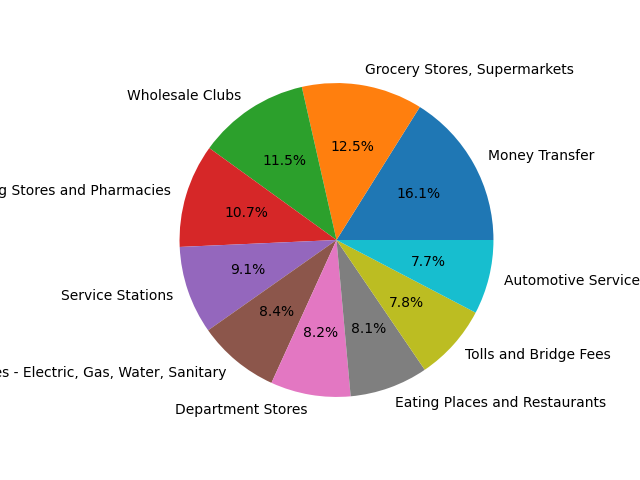

In [ ]:
plot_and_display(df,"pie")

## Step 5: Handling SQL Injection Attacks
### Purpose
Security is paramount in database systems, especially when accepting user inputs. This step demonstrates how to prevent **SQL injection attacks**, where malicious inputs (e.g., `'; DROP TABLE customers; --`) could harm the database. We’ll test a malicious query, show how the agent detects and rejects it, and explain the security measures in place.




In [ ]:
# Test a malicious query
malicious_query = "DROP TABLE customers;"
response = agent1.invoke({"input":  malicious_query})
print(response['output'])

I cannot execute DROP TABLE or any other DML statements that modify the database. If you have any other questions or need information from the database, feel free to ask!


## Step 6: Advanced Debugging and Monitoring
### Purpose
To ensure reliability, we’ll use advanced debugging and monitoring using LangChain’s `AgentExecutor` and structured logging. The `AgentExecutor` provides detailed insights into the query generation process, enhancing transparency.

LangChain allows you to log intermediate steps, catch errors, and inspect agent behavior in real time.

Here’s what it typically includes:

**verbose**=True	# Prints full reasoning, tool calls, SQL, and output

**return_intermediate_steps**=True	# Returns internal steps (e.g., tool calls and their inputs/outputs)

**handle_parsing_errors**=True	# Gracefully retries if parsing fails


In [ ]:
agent4 = create_sql_agent(
    llm=llm,
    toolkit=toolkit,
    prompt = custom_prompt,
    verbose=True,  # prints reasoning steps
    handle_parsing_errors=True, # Gracefully retries if parsing fails
    agent_type="openai-tools",
    agent_executor_kwargs={
        "memory": memory,
         "return_intermediate_steps": True  # gives you detailed inner logs
    }
)


In [ ]:
response = agent4.invoke({"input":  "top 10 categories by spend amount in 2015?","current_date": current_date})
print(response['output'])



> Entering new SQL Agent Executor chain...

Invoking: `sql_db_list_tables` with `{}`


cards, customers, merchant_category, transactions
Invoking: `sql_db_schema` with `{'table_names': 'transactions, merchant_category'}`



CREATE TABLE merchant_category (
	merchant_category_code TEXT, 
	merchant_description TEXT
)

/*
3 rows from merchant_category table:
merchant_category_code	merchant_description
5812	Eating Places and Restaurants
5541	Service Stations
7996	Amusement Parks, Carnivals, Circuses
*/


CREATE TABLE transactions (
	id BIGINT, 
	date TEXT, 
	client_id BIGINT, 
	card_id BIGINT, 
	amount_usd FLOAT, 
	use_chip TEXT, 
	merchant_id BIGINT, 
	merchant_city TEXT, 
	merchant_state TEXT, 
	zip FLOAT, 
	mcc BIGINT, 
	errors TEXT
)

/*
3 rows from transactions table:
id	date	client_id	card_id	amount_usd	use_chip	merchant_id	merchant_city	merchant_state	zip	mcc	errors
7475327	2010-01-01 00:01:00	1556	2972	-77.0	Swipe Transaction	59935	Beulah	ND	58523.0	5499	None
7475328	2010-01-01 0

/usr/local/lib/python3.11/dist-packages/langchain/chains/base.py:487: UserWarning: 'ConversationBufferMemory' got multiple output keys: dict_keys(['output', 'intermediate_steps']). The default 'output' key is being used. If this is not desired, please manually set 'output_key'.
  self.memory.save_context(inputs, outputs)


#Next Steps:


1. Add/Modify schema of tables and provide right datatypes of variables. Also, define primary and foreign key relationships
2.   Implement few shot exampels in the custom prompts
3.   Add streamlit UI
4.   Add Custom callbacks or tracers	Log outputs to a file, stream, or dashboard (e.g., LangSmith or OpenTelemetry)
5. Add custom layers to prevent for SQL injection attacks


